In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
import sys

# Path setup
current_dir = os.getcwd()
venv_path = os.path.abspath(os.path.join(current_dir, ".."))
data_path = os.path.join(venv_path, "Scripts", "data")

# Load labeled data
df = pd.read_csv(os.path.join(data_path, "processed", "labeled_data.csv"))

print(df.shape)
df.head()

(23171, 26)


,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,...,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended,full_review_text,clean_text,review_length,severity_label,risk_flag,severity_id
0,0,AB Aviation,9.0,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,...,2.0,1.0,3.0,yes,"""pretty decent airline"" Moroni to Moheli. Tu...",pretty decent airline moroni to moheli turned ...,67,Low,0,0
1,1,AB Aviation,1.0,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,...,2.0,1.0,2.0,no,"""Not a good airline"" Moroni to Anjouan. It is...",not a good airline moroni to anjouan it is a v...,140,Critical,1,3
2,2,AB Aviation,1.0,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,...,2.0,1.0,2.0,no,"""flight was fortunately short"" Anjouan to Dz...",flight was fortunately short anjouan to dzaoud...,71,Critical,1,3
3,3,Adria Airways,1.0,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,...,2.0,1.0,1.0,no,"""I will never fly again with Adria"" Please d...",i will never fly again with adria please do a ...,123,Critical,1,3
4,4,Adria Airways,1.0,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,...,1.0,1.0,1.0,no,"""it ruined our last days of holidays"" Do not ...",it ruined our last days of holidays do not boo...,117,Critical,1,3


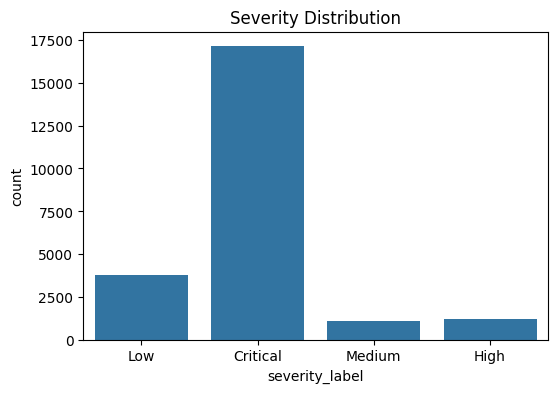

In [2]:
plt.figure(figsize=(6,4))
sns.countplot(x="severity_label", data=df)
plt.title("Severity Distribution")
plt.show()

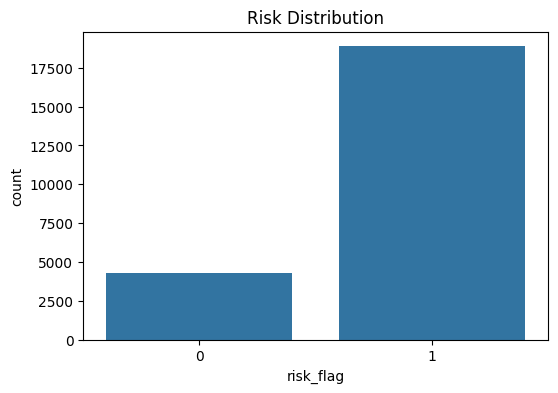

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x="risk_flag", data=df)
plt.title("Risk Distribution")
plt.show()

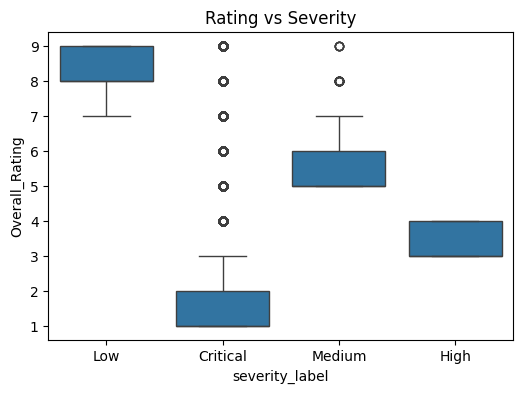

In [4]:
plt.figure(figsize=(6,4))
sns.boxplot(x="severity_label", y="Overall_Rating", data=df)
plt.title("Rating vs Severity")
plt.show()

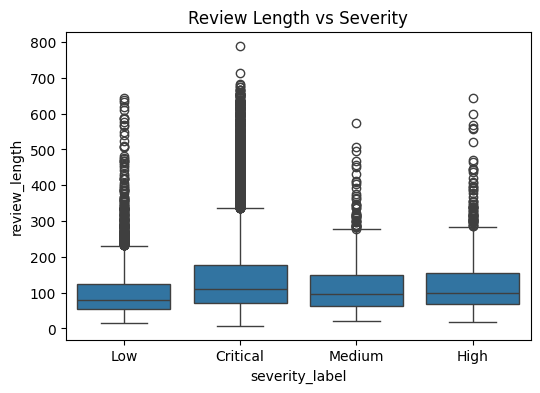

In [5]:
plt.figure(figsize=(6,4))
sns.boxplot(x="severity_label", y="review_length", data=df)
plt.title("Review Length vs Severity")
plt.show()

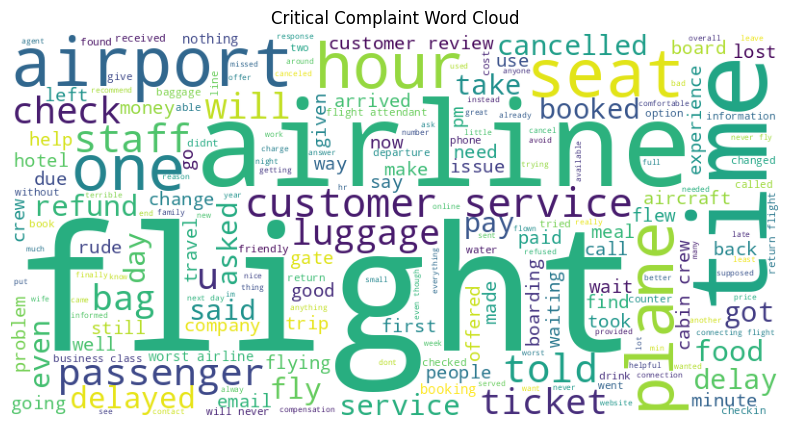

In [6]:
critical_text = " ".join(df[df["severity_label"]=="Critical"]["clean_text"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(critical_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Critical Complaint Word Cloud")
plt.show()

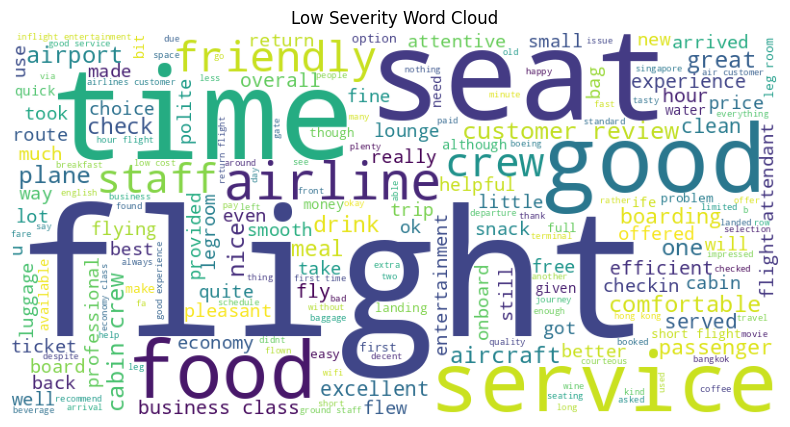

In [7]:
low_text = " ".join(df[df["severity_label"]=="Low"]["clean_text"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(low_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Low Severity Word Cloud")
plt.show()

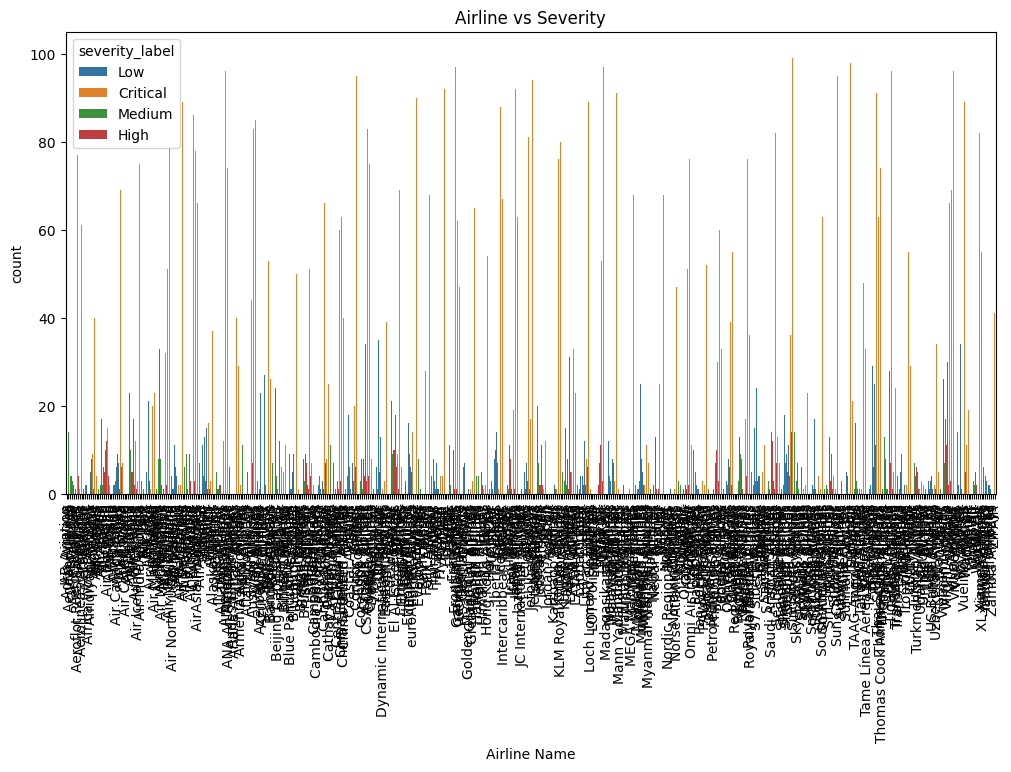

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(x="Airline Name", hue="severity_label", data=df)
plt.xticks(rotation=90)
plt.title("Airline vs Severity")
plt.show()

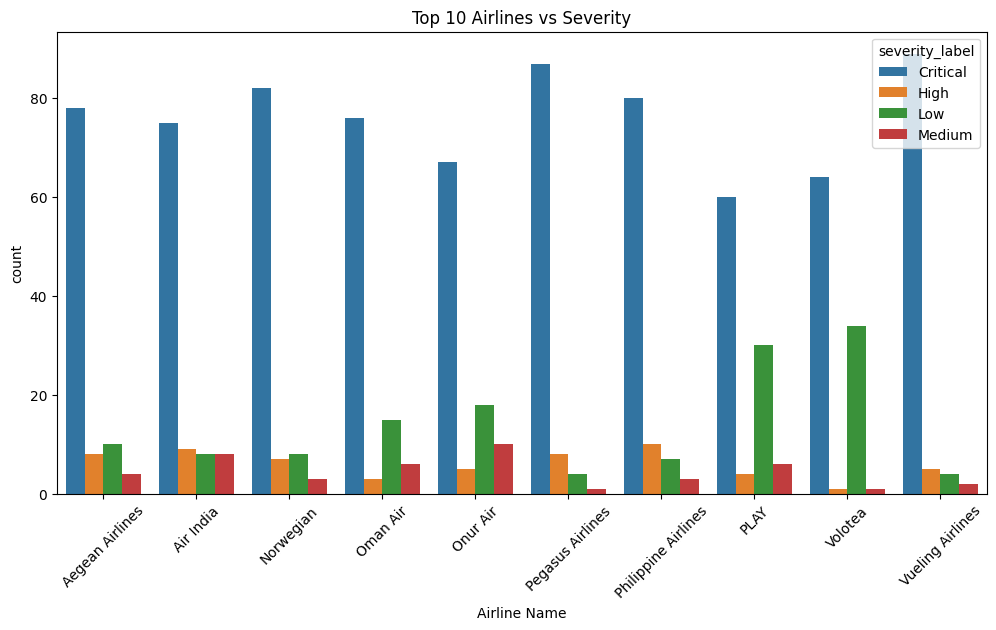

In [9]:
top_airlines = df["Airline Name"].value_counts().head(10).index
df_top = df[df["Airline Name"].isin(top_airlines)]

plt.figure(figsize=(12,6))
sns.countplot(data=df_top, x="Airline Name", hue="severity_label")
plt.xticks(rotation=45)
plt.title("Top 10 Airlines vs Severity")
plt.show()

In [9]:
import pandas as pd

df = pd.read_csv("D:/AI-Based Airline Complaint Severity Detection & Service Risk Classification System/venv/Scripts/data/processed/labeled_data.csv")  # update path

In [10]:
from textblob import TextBlob

df["sentiment_polarity"] = df["clean_text"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

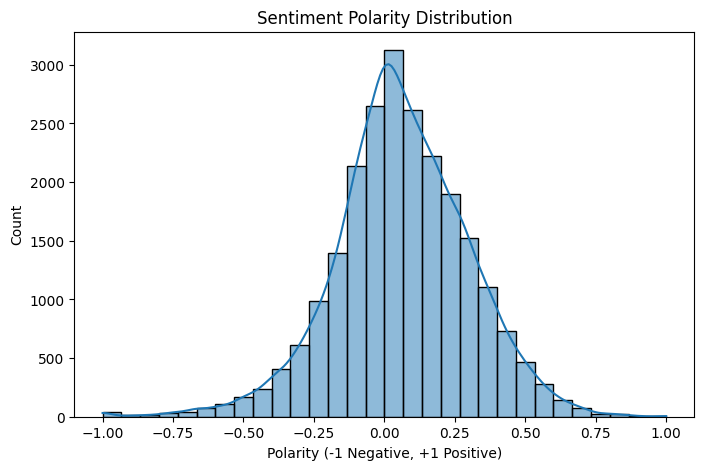

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["sentiment_polarity"], bins=30, kde=True)
plt.title("Sentiment Polarity Distribution")
plt.xlabel("Polarity (-1 Negative, +1 Positive)")
plt.ylabel("Count")
plt.show()

In [12]:
print(df.columns)

Index(['Unnamed: 0', 'Airline Name', 'Overall_Rating', 'Review_Title',
       'Review Date', 'Verified', 'Review', 'Aircraft', 'Type Of Traveller',
       'Seat Type', 'Route', 'Date Flown', 'Seat Comfort',
       'Cabin Staff Service', 'Food & Beverages', 'Ground Service',
       'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money',
       'Recommended', 'full_review_text', 'clean_text', 'review_length',
       'severity_label', 'risk_flag', 'severity_id', 'sentiment_polarity'],
      dtype='object')


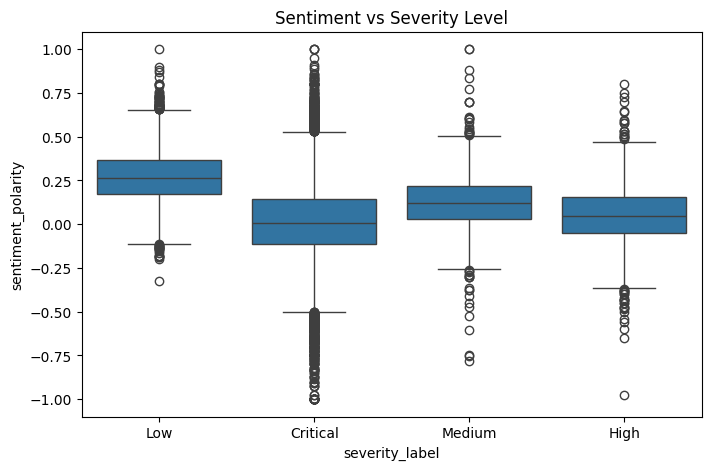

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x="severity_label", y="sentiment_polarity", data=df)
plt.title("Sentiment vs Severity Level")
plt.show()

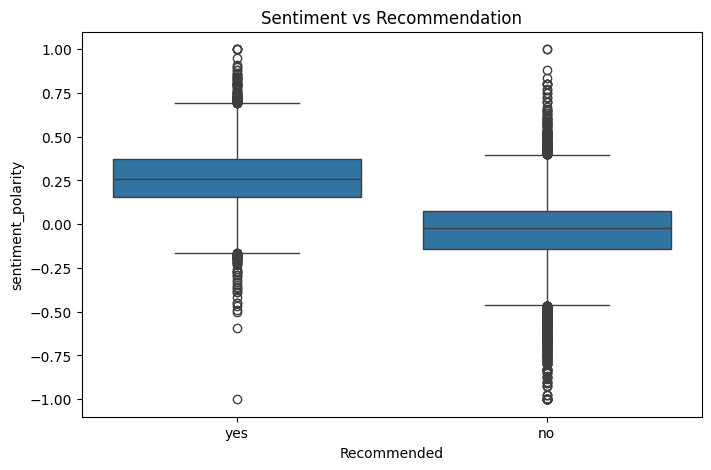

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Recommended", y="sentiment_polarity", data=df)
plt.title("Sentiment vs Recommendation")
plt.show()

In [15]:
negative_reviews = df[df["sentiment_polarity"] < -0.5]

negative_reviews["severity_label"].value_counts()

severity_label
Critical    370
High          6
Medium        5
Name: count, dtype: int64